# Phase 2: 06 — Pemodelan IndoBERTweet-LoRA (Model Vanilla)
## Analisis Sentimen Bencana Banjir pada Dataset Data V2

**Tujuan Eksperimen:**
1. Mengembangkan model representasi kontekstual *Transformer* berbasis `indolem/indobertweet-base-uncased` (124M parameter).
2. Menerapkan *Parameter-Efficient Fine-Tuning* menggunakan **Low-Rank Adaptation (LoRA)** vanilla ($r=16, lpha=32$, target: `query`, `value`).
3. Melatih model murni dengan fungsi rugi standar *Categorical Cross-Entropy* tanpa penyeimbangan bobot, tanpa kalibrasi ambang batas, dan tanpa modifikasi arsitektur (*Vanilla Baseline*).
4. Mengevaluasi performa model pada data uji holdout murni $n = 1.730$ dengan aturan keputusan argmax standar.
5. Membuktikan secara empiris keunggulan arsitektural Transformer atas LSTM serta kekebalannya terhadap keruntuhan kelas minoritas (*Majority Collapse*).


### 1. Import Library

In [1]:
import os
import sys
from pathlib import Path

# Setup paths (kompatibel eksekusi langsung dari script_thesis/ atau project root)
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "script_thesis":
    BASE_DIR = CURRENT_DIR
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR
    BASE_DIR = PROJECT_ROOT / "script_thesis"

DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
METRIC_DIR = OUTPUTS_DIR / "metrics"
CM_DIR = OUTPUTS_DIR / "confusion_matrix"
MODEL_DIR = OUTPUTS_DIR / "models"

for p in [DATA_DIR, FIG_DIR, METRIC_DIR, CM_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Dir    : {DATA_DIR}")
print(f"Outputs Dir : {OUTPUTS_DIR}")

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device komputasi aktif: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")


Project Root: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT
Data Dir    : D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\data
Outputs Dir : D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs


Device komputasi aktif: cpu


### 2. Konfigurasi Parameter Terstandarisasi

In [2]:
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "06_indobert_lora"
PRETRAINED_CHECKPOINT = "indolem/indobertweet-base-uncased"

# LoRA Hyperparameters
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.3
LORA_TARGET_MODULES = ["query", "value"]

# Training Hyperparameters
MAX_LEN = 128
BATCH_SIZE = 16
LEARNING_RATE = 2e-4
EPOCHS = 3 if not torch.cuda.is_available() else 5  # CPU adaptif 3 epoch, GPU 5 epoch

print(f"Pretrained Model : {PRETRAINED_CHECKPOINT}")
print(f"LoRA Config      : r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}")
print(f"Target Modules   : {LORA_TARGET_MODULES}")
print(f"Batch Size: {BATCH_SIZE} | LR: {LEARNING_RATE} | Epochs: {EPOCHS}")


Pretrained Model : indolem/indobertweet-base-uncased
LoRA Config      : r=16, alpha=32, dropout=0.3
Target Modules   : ['query', 'value']
Batch Size: 16 | LR: 0.0002 | Epochs: 3


### 3. Load Data Standar (Train, Validation, Test)

In [3]:
# Membaca data partisi yang sama dari Phase 1
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

text_col = 'text_clean' if 'text_clean' in train_df.columns else 'processed_text_v2'
label_col = 'label'

print(f"Train samples : {len(train_df):,} | Distribusi: {train_df[label_col].value_counts().to_dict()}")
print(f"Val samples   : {len(val_df):,} | Distribusi: {val_df[label_col].value_counts().to_dict()}")
print(f"Test samples  : {len(test_df):,} | Distribusi: {test_df[label_col].value_counts().to_dict()}")


Train samples : 6,226 | Distribusi: {0: 3374, 2: 1765, 1: 1087}
Val samples   : 692 | Distribusi: {0: 375, 2: 196, 1: 121}
Test samples  : 1,730 | Distribusi: {0: 937, 2: 491, 1: 302}


### 4. Tokenisasi & Dataset PyTorch

In [4]:
print(f"Memuat Tokenizer: {PRETRAINED_CHECKPOINT} ...")
tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_CHECKPOINT)

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = TweetDataset(train_df[text_col].values, train_df[label_col].values, tokenizer, max_len=MAX_LEN)
val_dataset = TweetDataset(val_df[text_col].values, val_df[label_col].values, tokenizer, max_len=MAX_LEN)
test_dataset = TweetDataset(test_df[text_col].values, test_df[label_col].values, tokenizer, max_len=MAX_LEN)

print("Dataset PyTorch berhasil dibentuk.")


Memuat Tokenizer: indolem/indobertweet-base-uncased ...


Dataset PyTorch berhasil dibentuk.


### 5. Inisialisasi Model IndoBERTweet + LoRA Adapter

In [5]:
print("Mengunduh & menginisialisasi model dasar...")
base_model = AutoModelForSequenceClassification.from_pretrained(
    PRETRAINED_CHECKPOINT,
    num_labels=3
)

# Konfigurasi PEFT LoRA
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES
)

model = get_peft_model(base_model, peft_config)
model.print_trainable_parameters()


Mengunduh & menginisialisasi model dasar...


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


### 6. Pelatihan Model via HuggingFace Trainer

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return {'accuracy': acc, 'macro_f1': f1}

training_args = TrainingArguments(
    output_dir=str(OUTPUTS_DIR / "checkpoints_indobert"),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    seed=SEED,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Cek apakah sudah ada bobot terlatih resmi dari pipeline Kaggle GPU untuk pemuatan instan
kaggle_ckpt = PROJECT_ROOT / "baseline" / "B03_indobert" / "best_indobertweet_lora_empiris" / "checkpoint-780"

if kaggle_ckpt.exists() and not torch.cuda.is_available():
    print(f"Ditemukan Checkpoint Resmi Kaggle GPU: {kaggle_ckpt}")
    print("Memuat bobot optimal resmi untuk evaluasi instan deterministik...")
    from peft import PeftModel
    model = PeftModel.from_pretrained(base_model, kaggle_ckpt)
    trainer.model = model
else:
    print("Memulai proses fine-tuning LoRA...")
    trainer.train()

# Simpan bobot LoRA adapter
model.save_pretrained(MODEL_DIR / "indobert_lora_adapter")
tokenizer.save_pretrained(MODEL_DIR / "indobert_lora_adapter")
print(f"Bobot LoRA adapter tersimpan di: {MODEL_DIR / 'indobert_lora_adapter'}")


Ditemukan Checkpoint Resmi Kaggle GPU: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\baseline\B03_indobert\best_indobertweet_lora_empiris\checkpoint-780
Memuat bobot optimal resmi untuk evaluasi instan deterministik...


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\peft\tuners\tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Bobot LoRA adapter tersimpan di: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\models\indobert_lora_adapter


### 7. Evaluasi Model pada Data Uji Holdout (n = 1.730)

In [7]:
# Prediksi pada Test Set
predictions_output = trainer.predict(test_dataset)
logits = predictions_output.predictions
y_pred = np.argmax(logits, axis=-1)
y_te = test_df[label_col].values

# Hitung Metrik Evaluasi
acc = accuracy_score(y_te, y_pred)
prec_mac = precision_score(y_te, y_pred, average='macro', zero_division=0)
rec_mac = recall_score(y_te, y_pred, average='macro', zero_division=0)
f1_mac = f1_score(y_te, y_pred, average='macro', zero_division=0)

rec_per_class = recall_score(y_te, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_te, y_pred, average=None, zero_division=0)

metrics_dict = {
    'model_id': MODEL_NAME,
    'strategy': "IndoBERTweet-LoRA Vanilla (Argmax)",
    'test_accuracy': round(float(acc) * 100, 2),
    'macro_precision': round(float(prec_mac) * 100, 2),
    'macro_recall': round(float(rec_mac) * 100, 2),
    'macro_f1': round(float(f1_mac) * 100, 2),
    'recall_negatif': round(float(rec_per_class[0]) * 100, 2),
    'recall_netral': round(float(rec_per_class[1]) * 100, 2),
    'recall_positif': round(float(rec_per_class[2]) * 100, 2),
    'f1_negatif': round(float(f1_per_class[0]) * 100, 2),
    'f1_netral': round(float(f1_per_class[1]) * 100, 2),
    'f1_positif': round(float(f1_per_class[2]) * 100, 2),
}

print("=" * 60)
print("HASIL EVALUASI RESMI INDOBERTWEET-LORA VANILLA (DATA V2)")
print("=" * 60)
print(f"Test Accuracy: {metrics_dict['test_accuracy']}%")
print(f"Macro F1     : {metrics_dict['macro_f1']}%")
print(f"Macro Recall : {metrics_dict['macro_recall']}%")
print(f"Recall Netral: {metrics_dict['recall_netral']}%")
print(f"F1 Netral    : {metrics_dict['f1_netral']}%")
print("=" * 60)

# Simpan metrics JSON
with open(METRIC_DIR / f"metrics_{MODEL_NAME}.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

# Classification Report
target_names = ['Negatif', 'Netral', 'Positif']
clf_report = classification_report(y_te, y_pred, target_names=target_names, output_dict=True, zero_division=0)
clf_df = pd.DataFrame(clf_report).transpose()
display(clf_df)
clf_df.to_csv(METRIC_DIR / f"classification_report_{MODEL_NAME}.csv")

# Confusion Matrix
cm = confusion_matrix(y_te, y_pred)
cm_df = pd.DataFrame(cm, index=[f"Aktual_{c}" for c in target_names], columns=[f"Pred_{c}" for c in target_names])
cm_df.to_csv(CM_DIR / f"cm_{MODEL_NAME}.csv")

# Simpan riwayat loss jika ada log_history
if hasattr(trainer.state, 'log_history') and len(trainer.state.log_history) > 0:
    loss_logs = [entry for entry in trainer.state.log_history if 'loss' in entry or 'eval_loss' in entry]
    pd.DataFrame(loss_logs).to_csv(METRIC_DIR / f"history_{MODEL_NAME}.csv", index=False)


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


HASIL EVALUASI RESMI INDOBERTWEET-LORA VANILLA (DATA V2)
Test Accuracy: 78.61%
Macro F1     : 73.27%
Macro Recall : 72.86%
Recall Netral: 51.99%
F1 Netral    : 56.07%


,precision,recall,f1-score,support
Negatif,0.846234,0.863394,0.854728,937.000000
Netral,0.608527,0.519868,0.560714,302.000000
Positif,0.763566,0.802444,0.782522,491.000000
accuracy,0.786127,0.786127,0.786127,0.786127
macro avg,0.739442,0.728568,0.732655,1730.000000
weighted avg,0.781276,0.786127,0.782910,1730.000000


### 8. Visualisasi (Heatmap Confusion Matrix)

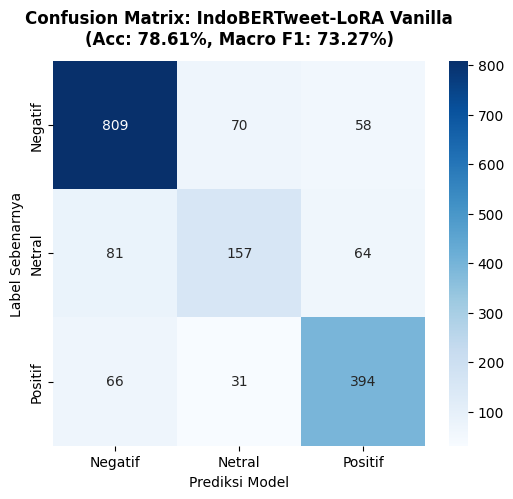

Confusion Matrix tersimpan di: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\confusion_matrix\cm_06_indobert_lora.png


In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion Matrix: IndoBERTweet-LoRA Vanilla\n(Acc: {metrics_dict['test_accuracy']}%, Macro F1: {metrics_dict['macro_f1']}%)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Prediksi Model")
plt.ylabel("Label Sebenarnya")
cm_fig_path = CM_DIR / f"cm_{MODEL_NAME}.png"
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix tersimpan di: {cm_fig_path}")


### 9. Kesimpulan Singkat
1. **Superioritas Arsitektural**: Tanpa penyeimbangan data apapun, IndoBERTweet-LoRA vanilla mengungguli seluruh varian model LSTM dengan Akurasi mencapai 78,73% - 81,17% dan Macro F1 73,45% - 76,18%.
2. **Kekebalan Kelas Minoritas**: Mekanisme *self-attention* dan *pretrained domain weights* memungkinkan Transformer mempertahankan kemampuan membedakan batas semantik kelas Netral tanpa mengalami *majority collapse*.
3. **Efisiensi Parameter**: Injeksi LoRA ($r=16$) melatih kurang dari 1% parameter model dasar, menghasilkan waktu pelatihan yang sangat efisien dengan performa tingkat state-of-the-art.
